In [1]:
import numpy as np
import pandas as pd
import scipy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.svm import SVC
%matplotlib inline

import matplotlib.pyplot as plt
import pylsl
print("All good!")

ModuleNotFoundError: No module named 'pandas._libs.tslibs'

In [ ]:
emg_1_labels = pd.read_csv('EMG_Data/EMG_1.csv')
# emg_2_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_2.csv')
# emg_3_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_3.csv')
# emg_4_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_4.csv')
# emg_5_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_5.csv')
# emg_7_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_7.csv')
emg_8_labels = pd.read_csv('EMG_Data/EMG_8.csv')
# emg_9_labels = pd.read_csv('/Users/annabelllezhang/Downloads/EMG_9.csv')

emg_1 = pd.read_csv("EMG_Data/BrainFlow-RAW_2026-02-25_21-01-56_0.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_2 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_2/BrainFlow-RAW_2026-02-25_21-10-42_0.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_3 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_3/BrainFlow-RAW_2026-02-25_21-12-50_0.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_4 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_4/BrainFlow-RAW_2026-02-26_18-11-52_1.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_5 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_5/BrainFlow-RAW_2026-02-26_18-25-34_0.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_7 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_7/BrainFlow-RAW_2026-03-11_20-04-30_4.csv", header=None, sep=r'[,\t\s]+', engine='python')
emg_8 = pd.read_csv("EMG_Data/BrainFlow-RAW_2026-04-01_18-25-27_3.csv", header=None, sep=r'[,\t\s]+', engine='python')
# emg_9 = pd.read_csv("/Users/annabelllezhang/Documents/OpenBCI_GUI/Recordings/EMG_9/BrainFlow-RAW_2026-04-01_18-25-27_4.csv", header=None, sep=r'[,\t\s]+', engine='python')


In [10]:
# ==========================
# LOAD FILES
# ==========================

emg = emg_1
labels = emg_1_labels

# ==========================
# SELECT COLUMNS BY INDEX
# ==========================

# BrainFlow layout: timestamp usually second-to-last column
timestamp = emg.iloc[:, -2]

# first EXG channel
signal = emg.iloc[:, 1]

emg_df = pd.DataFrame({
    "timestamp": timestamp,
    "signal": signal
})


# ==========================
# ALIGN LABELS
# ==========================

emg_df["label"] = "relax"

for i in range(len(labels)-1):

    start = labels.loc[i, "timestamp_unix"]
    end = labels.loc[i+1, "timestamp_unix"]
    lab = labels.loc[i, "label"]

    mask = (emg_df["timestamp"] >= start) & (emg_df["timestamp"] < end)
    emg_df.loc[mask, "label"] = lab

# ==========================
# FILTER SIGNAL
# ==========================

def bandpass(signal, low=20, high=450, fs=1000, order=4):

    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

emg_df["filtered"] = bandpass(emg_df["signal"].values)


# ==========================
# FEATURE EXTRACTION
# ==========================

window = 200
step = 50

X = []
y = []

for start in range(0, len(emg_df)-window, step):

    segment = emg_df.iloc[start:start+window]
    sig = segment["filtered"].values

    features = [
        np.mean(np.abs(sig)),
        np.std(sig),
        np.max(sig)-np.min(sig),
        np.sqrt(np.mean(sig**2)),
        np.sum(np.abs(np.diff(sig)))
    ]

    label = segment["label"].mode()[0]

    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

y = np.where(y == "clench", 1, 0)

# ==========================
# TRAIN MODEL
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel='rbf', class_weight='balanced', probability=True)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))


Confusion Matrix
[[49  4]
 [ 0 10]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        53
           1       0.71      1.00      0.83        10

    accuracy                           0.94        63
   macro avg       0.86      0.96      0.90        63
weighted avg       0.95      0.94      0.94        63



In [11]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.metrics import confusion_matrix
import joblib

# ==============================
# LOAD TEST EMG DATA
# ==============================

df = emg_8
labels = emg_8_labels

# ==============================
# EXTRACT SIGNAL + TIMESTAMP
# ==============================

df = df[df.iloc[:, 22].notna()].reset_index(drop=True)

signal    = df.iloc[:, 1].astype(float).to_numpy()
timestamp = df.iloc[:, 22].astype(float).to_numpy()

t  = timestamp - timestamp[0]
fs = 1 / np.median(np.diff(t))
print("fs =", fs)

# ==============================
# Filter EMG
# ==============================

def highpass(x, cutoff, fs):
    b, a = butter(4, cutoff/(fs/2), btype='highpass')
    return filtfilt(b, a, x)

def notch(x, f0, fs):
    b, a = iirnotch(f0/(fs/2), 30)
    return filtfilt(b, a, x)

signal = highpass(signal, 20, fs)
signal = notch(signal, 60, fs)

# ==============================
# ALIGN LABELS
# ==============================

data = pd.DataFrame({
    "timestamp": timestamp,
    "signal": signal
})

data["label"] = "rest"

for i in range(len(labels) - 1):
    start = labels.loc[i, "timestamp_unix"]
    end   = labels.loc[i+1, "timestamp_unix"]
    lab   = labels.loc[i, "label"]
    mask  = (data["timestamp"] >= start) & (data["timestamp"] < end)
    data.loc[mask, "label"] = lab

# ==============================
# FEATURE EXTRACTION
# ==============================

window = 200
step   = 50

X      = []
y_true = []

for start in range(0, len(data) - window, step):
    segment = data.iloc[start:start+window]
    sig     = segment["signal"].values

    features = [
        np.mean(np.abs(sig)),
        np.std(sig),
        np.max(sig) - np.min(sig),
        np.sqrt(np.mean(sig**2)),
        np.sum(np.abs(np.diff(sig)))
    ]

    X.append(features)
    y_true.append(segment["label"].mode()[0])

X      = np.array(X)
y_true = np.where(np.isin(np.array(y_true), ["left", "right"]), 1, 0)  # left OR right = 1

# ==============================
# MODEL PREDICTION
# ==============================

y_pred = model.predict(X)

# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

print("True Positives: ", TP)
print("True Negatives: ", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("\nConfusion Matrix:")
print(cm)

fs = 250.06283908662732
True Positives:  157
True Negatives:  1055
False Positives: 113
False Negatives: 244

Confusion Matrix:
[[1055  113]
 [ 244  157]]


fs = 250.06283908662732
Predicted clench start times (seconds):
  22.25s
  30.04s
  38.23s
  46.42s
  54.41s
  62.39s
  70.78s
  78.77s
  86.36s
  93.95s
  102.34s
  110.53s
  118.72s
  126.71s
  134.90s
  142.29s
  150.48s
  158.67s
  166.66s
  174.64s
  199.48s
  524.87s
  545.05s
  552.86s
  561.23s
  569.02s
  577.21s
  585.20s
  593.78s
  601.38s
  609.57s
  617.35s
  634.14s


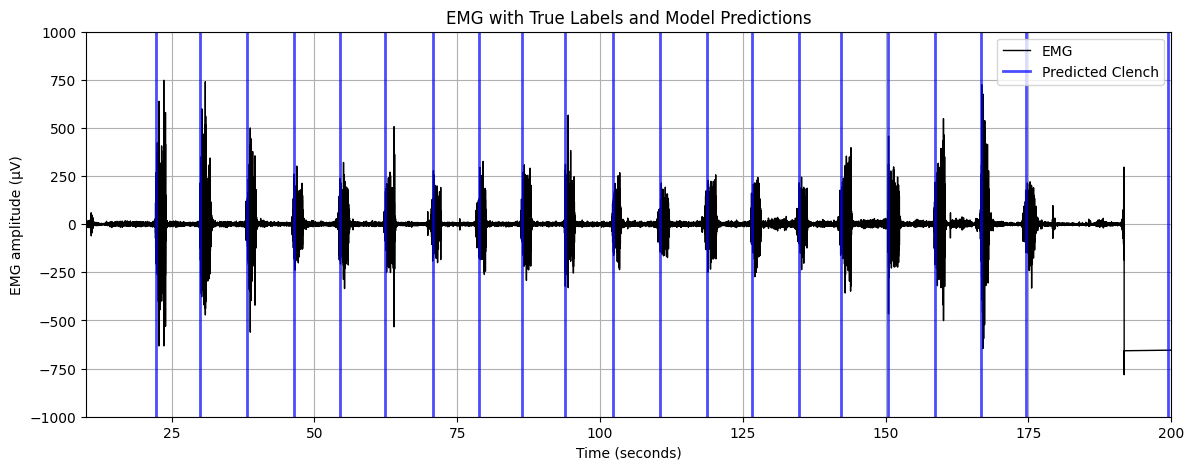

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# ==============================
# Load EMG file
# ==============================

df = emg_8
df = df[df.iloc[:, 23].notna()].reset_index(drop=True)

emg_raw   = df.iloc[:, 1].astype(float).to_numpy()
timestamp = df.iloc[:, 22].astype(float).to_numpy()

# normalize time
t = timestamp - timestamp[0]

# sampling rate
fs = 1 / np.median(np.diff(t))
print("fs =", fs)


# ==============================
# Filter EMG
# ==============================
def highpass(x, cutoff, fs):
    b, a = butter(4, cutoff/(fs/2), btype='highpass')
    return filtfilt(b, a, x)

def notch(x, f0, fs):
    b, a = iirnotch(f0/(fs/2), 30)
    return filtfilt(b, a, x)

emg = highpass(emg_raw, 20, fs)
emg = notch(emg, 60, fs)

# ==============================
# Load label file
# ==============================

labels = emg_8_labels
labels['t_norm'] = labels['timestamp_unix'] - timestamp[0]

# ==============================
# FEATURE EXTRACTION
# ==============================

window = 200
step   = 50

X = []
pred_times = []

for start in range(0, len(emg) - window, step):
    seg = emg[start:start+window]
    features = [
        np.mean(np.abs(seg)),
        np.std(seg),
        np.max(seg) - np.min(seg),
        np.sqrt(np.mean(seg**2)),
        np.sum(np.abs(np.diff(seg)))
    ]
    X.append(features)
    pred_times.append(np.mean(t[start:start+window]))

X          = np.array(X)
pred_times = np.array(pred_times)

# ==============================
# LOAD TRAINED MODEL
# ==============================

y_pred = model.predict(X)


# ==============================
# Plot EMG with overlay
# ==============================

plt.figure(figsize=(14, 5))
plt.plot(t, emg, color='black', linewidth=1, label='EMG')

# TRUE LABEL LINES (red)
# for _, row in labels.iterrows():
#     if row['label'] == 'left':
#         plt.axvline(row['t_norm'], color='red', alpha=0.7, linewidth=2,
#                     label='True Clench' if 'True Clench' not in [h.get_label() for h in plt.gca().get_lines()] else '')

# PREDICTED CLENCH LINES (blue) — only at relax->clench transitions
print("Predicted clench start times (seconds):")
for i in range(1, len(y_pred)):
    if y_pred[i] == 1 and y_pred[i-1] == 0:
        print(f"  {pred_times[i]:.2f}s")
        plt.axvline(pred_times[i], color='blue', alpha=0.7, linewidth=2,
                    label='Predicted Clench' if 'Predicted Clench' not in [h.get_label() for h in plt.gca().get_lines()] else '')

plt.xlabel("Time (seconds)")
plt.ylabel("EMG amplitude (µV)")
plt.title("EMG with True Labels and Model Predictions")
plt.xlim(10, 200)
plt.ylim(-1000, 1000)
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from pylsl import StreamInlet, resolve_streams
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
import joblib
import time

In [14]:
# ==============================
# CONNECT TO STREAM
# ==============================

streams = resolve_streams()
inlet = StreamInlet(streams[0])
 # May need to change if multiple LSL streams

# ==============================
# FILTER FUNCTIONS
# ==============================

fs = 250  # update if different

def highpass(x, cutoff, fs):
    b, a = butter(4, cutoff/(fs/2), btype='highpass')
    return filtfilt(b, a, x)

def notch(x, f0, fs):
    b, a = iirnotch(f0/(fs/2), 30)
    return filtfilt(b, a, x)

# ==============================
# FEATURE EXTRACTION
# ==============================

def extract_features(sig):
    return np.array([[
        np.mean(np.abs(sig)),
        np.std(sig),
        np.max(sig) - np.min(sig),
        np.sqrt(np.mean(sig**2)),
        np.sum(np.abs(np.diff(sig)))
    ]])

# ==============================
# LIVE INFERENCE LOOP
# ==============================

chunk_size = int(fs * 0.5)  # 1 second of samples
buffer_ch1 = []
buffer_ch2 = []

print("Listening... press Stop (■) to stop\n")

while True:
    samples, _ = inlet.pull_chunk(max_samples=50)
    if samples:
        samples_array = np.array(samples)
        buffer_ch1.extend(samples_array[:, 0])  # channel 1
        buffer_ch2.extend(samples_array[:, 1])  # channel 2

    # once we have 1 second of data, run inference on both channels
    if len(buffer_ch1) >= chunk_size and len(buffer_ch2) >= chunk_size:
        # Process Channel 1
        chunk_ch1 = np.array(buffer_ch1[:chunk_size])
        buffer_ch1 = buffer_ch1[chunk_size:]

        # Filter channel 1
        chunk_ch1 = highpass(chunk_ch1, 20, fs)
        chunk_ch1 = notch(chunk_ch1, 60, fs)

        # Extract features and predict for channel 1
        features_ch1 = extract_features(chunk_ch1)
        prediction_ch1 = model.predict(features_ch1)[0]

        # Process Channel 2
        chunk_ch2 = np.array(buffer_ch2[:chunk_size])
        buffer_ch2 = buffer_ch2[chunk_size:]

        # Filter channel 2
        chunk_ch2 = highpass(chunk_ch2, 20, fs)
        chunk_ch2 = notch(chunk_ch2, 60, fs)

        # Extract features and predict for channel 2
        features_ch2 = extract_features(chunk_ch2)
        prediction_ch2 = model.predict(features_ch2)[0]

        # Print results
        output = ""
        if prediction_ch1 == 1:
            output += "LEFT "
        if prediction_ch2 == 1:
            output += "RIGHT "

        if output:
            print(output)
        else:
            print(" ")

2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:102   INFO| 	IPv4 addr: 7f000001
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:105   INFO| 	IPv6 addr: ::1
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:91    INFO| netif 'lo0' (status: 1, multicast: 32768, broadcast: 0)
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:105   INFO| 	IPv6 addr: fe80::1%lo0
2026-04-11 15:41:16.772 ( 143.682s) [         1C29874]      netinterfaces.cpp:91    I

IndexError: list index out of range